In [111]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/hour.csv
/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/Readme.txt
/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/day.csv


In [112]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score, KFold)
from sklearn.preprocessing  import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model   import (LinearRegression, Ridge, Lasso,ElasticNet, HuberRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score, mean_absolute_percentage_error)


In [113]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/day.csv')
print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape : (731, 16)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [114]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [115]:
df.info




<bound method DataFrame.info of      instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0          1  2011-01-01       1   0     1        0        6           0   
1          2  2011-01-02       1   0     1        0        0           0   
2          3  2011-01-03       1   0     1        0        1           1   
3          4  2011-01-04       1   0     1        0        2           1   
4          5  2011-01-05       1   0     1        0        3           1   
..       ...         ...     ...  ..   ...      ...      ...         ...   
726      727  2012-12-27       1   1    12        0        4           1   
727      728  2012-12-28       1   1    12        0        5           1   
728      729  2012-12-29       1   1    12        0        6           0   
729      730  2012-12-30       1   1    12        0        0           0   
730      731  2012-12-31       1   1    12        0        1           1   

     weathersit      temp     atemp       hum  windspee

In [116]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [117]:
df.nunique()

instant       731
dteday        731
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          499
atemp         690
hum           595
windspeed     650
casual        606
registered    679
cnt           696
dtype: int64

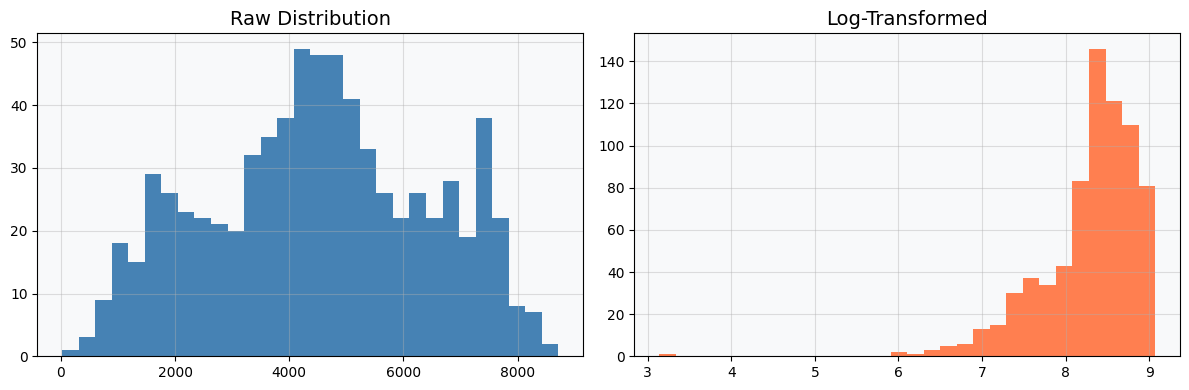

In [118]:
#target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['cnt'], bins=30, color='steelblue')
axes[0].set_title('Raw Distribution')

axes[1].hist(np.log1p(df['cnt']), bins=30, color='coral')
axes[1].set_title('Log-Transformed')

plt.tight_layout()
plt.show()

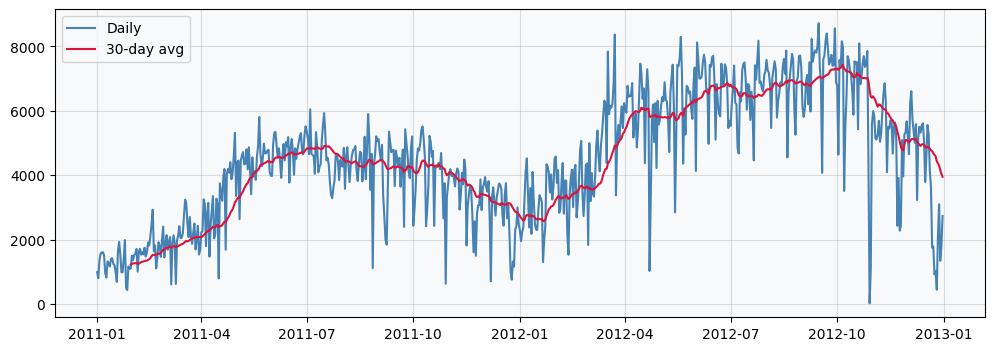

In [119]:
# ── 3.2 Rentals over Time ─────────────────────────────────────────────────────
df['dteday'] = pd.to_datetime(df['dteday'])

plt.figure(figsize=(12, 4))
plt.plot(df['dteday'], df['cnt'], color='steelblue', label='Daily')
plt.plot(df['dteday'], df['cnt'].rolling(30).mean(), color='crimson', label='30-day avg')
plt.legend()
plt.show()

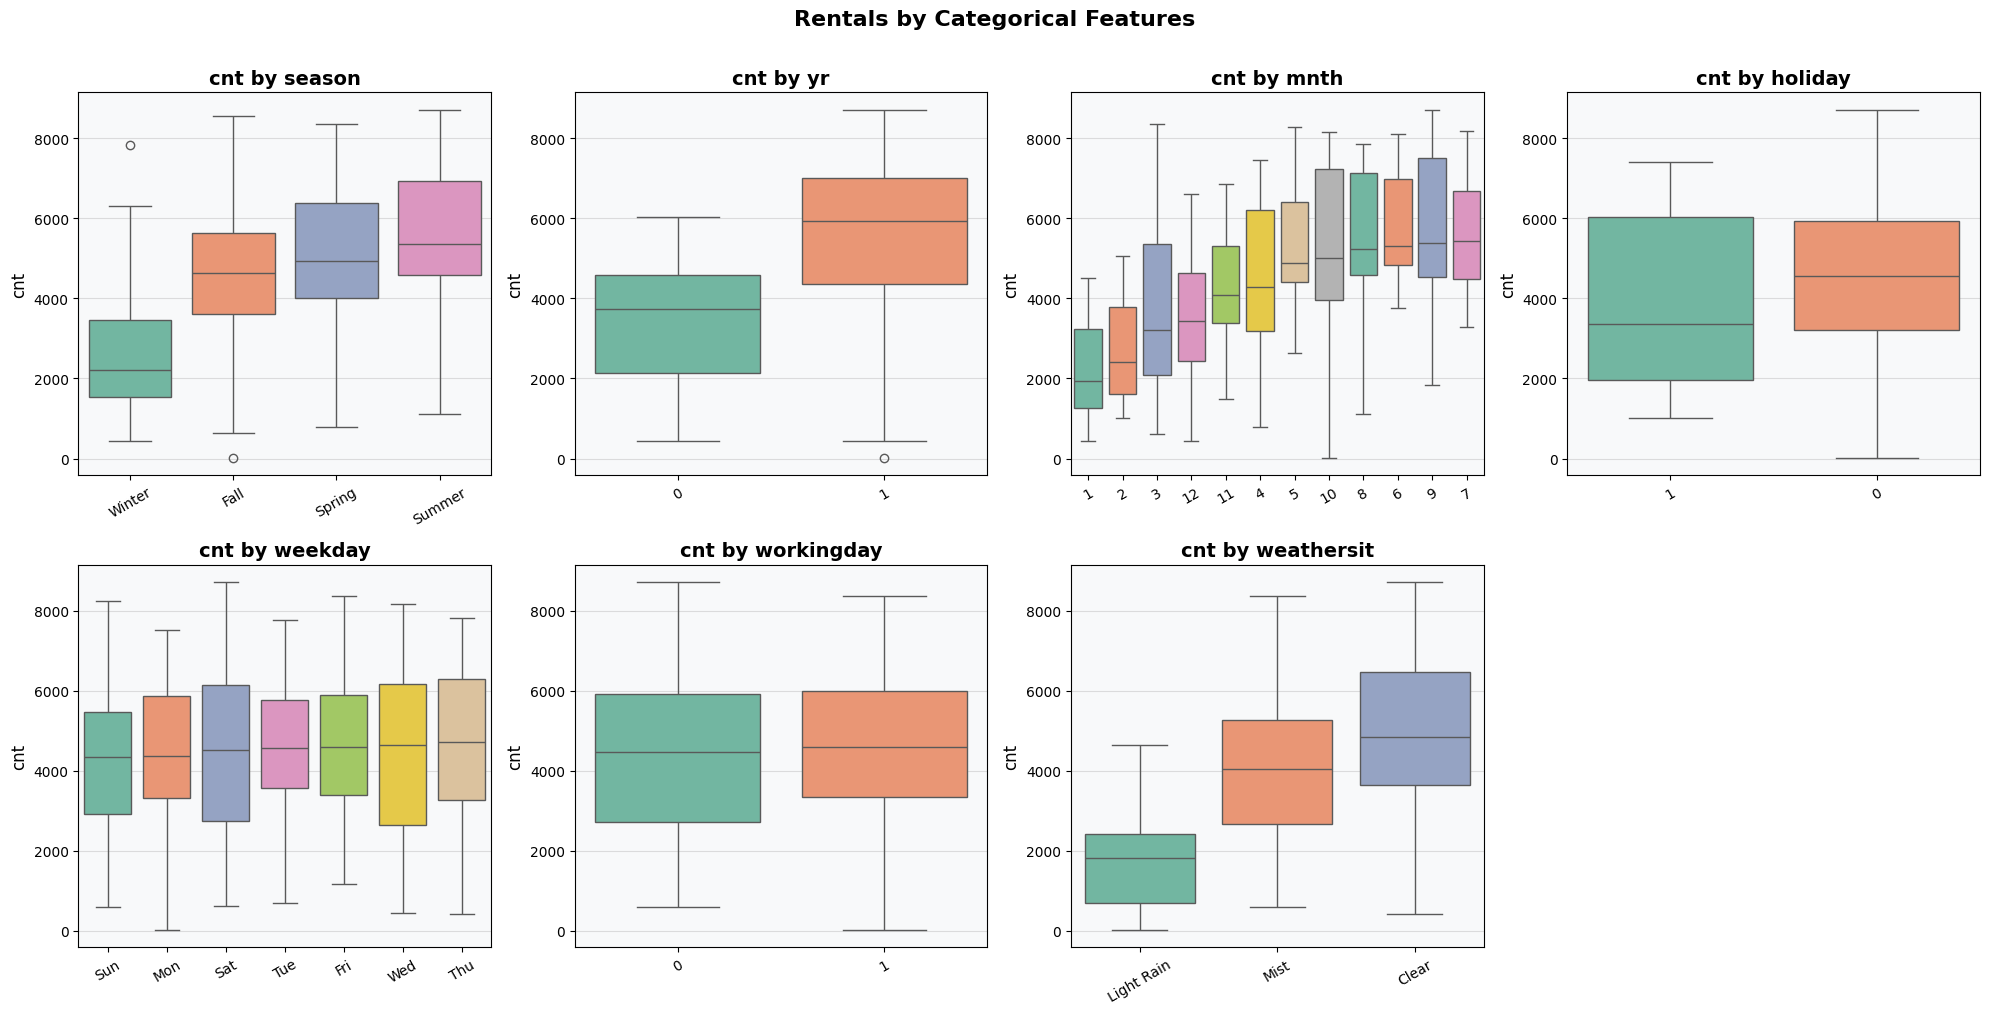

In [120]:
# ── 3.3 Categorical Features vs cnt ──────────────────────────────────────────
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
season_map   = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'}
weather_map  = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}
weekday_map  = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tmp = df.copy()
    if col == 'season':   tmp[col] = tmp[col].map(season_map)
    elif col == 'weathersit': tmp[col] = tmp[col].map(weather_map)
    elif col == 'weekday':    tmp[col] = tmp[col].map(weekday_map)
    
    order = tmp.groupby(col)['cnt'].median().sort_values().index
    sns.boxplot(data=tmp, x=col, y='cnt', order=order,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'cnt by {col}', fontweight='bold')
    axes[i].set_xlabel('')
    for label in axes[i].get_xticklabels():
        label.set_rotation(30)

axes[-1].axis('off')
plt.suptitle('Rentals by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

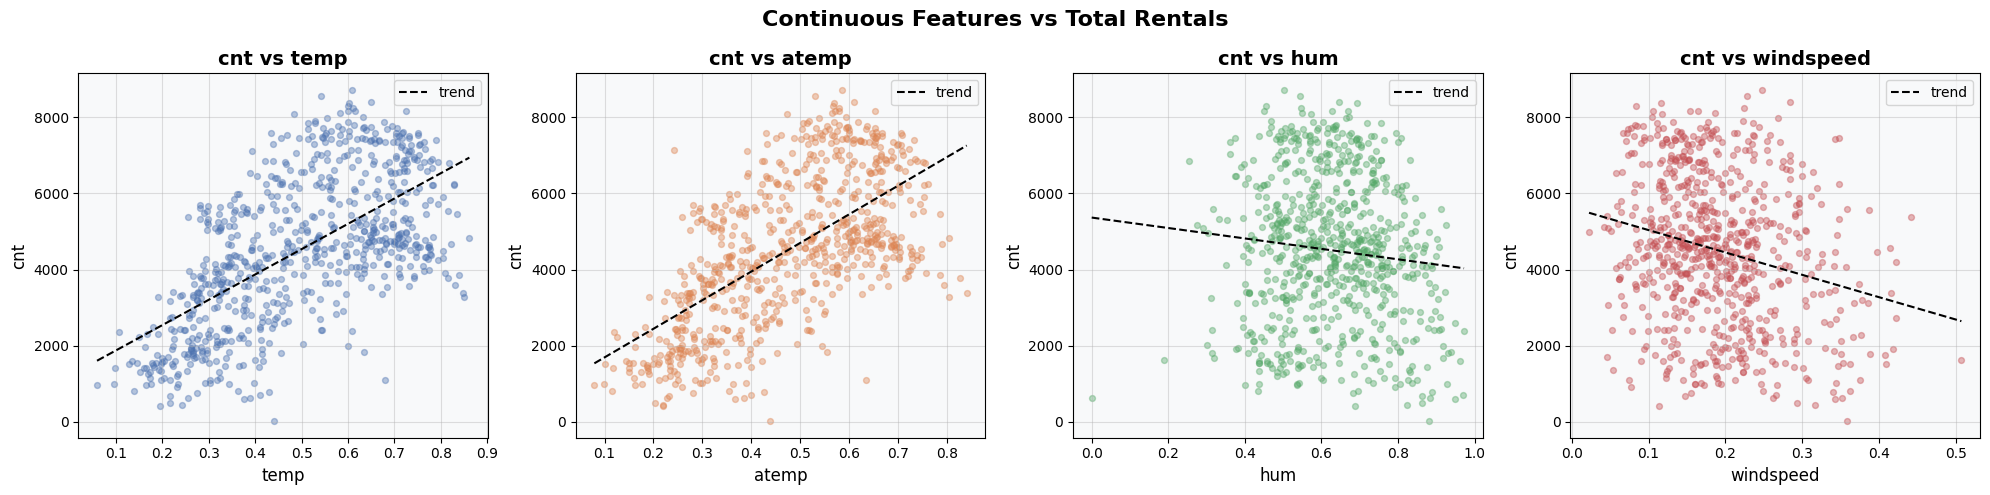

In [121]:
# ── 3.4 Numeric Features vs cnt ──────────────────────────────────────────────
num_cols = ['temp', 'atemp', 'hum', 'windspeed']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, c in zip(axes, num_cols, colors):
    ax.scatter(df[col], df['cnt'], alpha=0.4, s=18, color=c)
    # Trend line
    z = np.polyfit(df[col], df['cnt'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, p(x_range), 'k--', linewidth=1.5, label='trend')
    ax.set_title(f'cnt vs {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('cnt')
    ax.legend()

plt.suptitle('Continuous Features vs Total Rentals', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

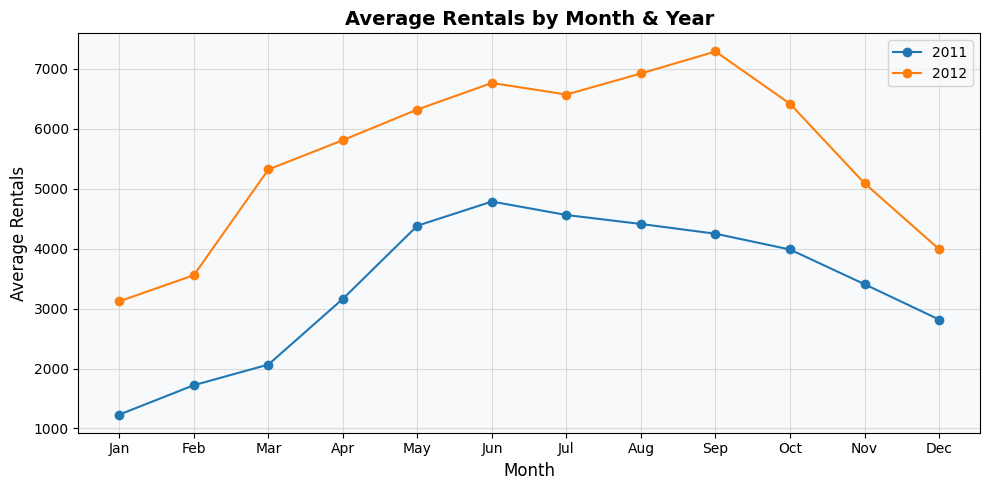

In [122]:
fig, ax = plt.subplots(figsize=(10, 5))

monthly = df.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()

for yr, grp in monthly.groupby('yr'):
    label = '2011' if yr == 0 else '2012'
    ax.plot(grp['mnth'], grp['cnt'], marker='o', label=label)

ax.set_title('Average Rentals by Month & Year', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rentals')
ax.legend()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

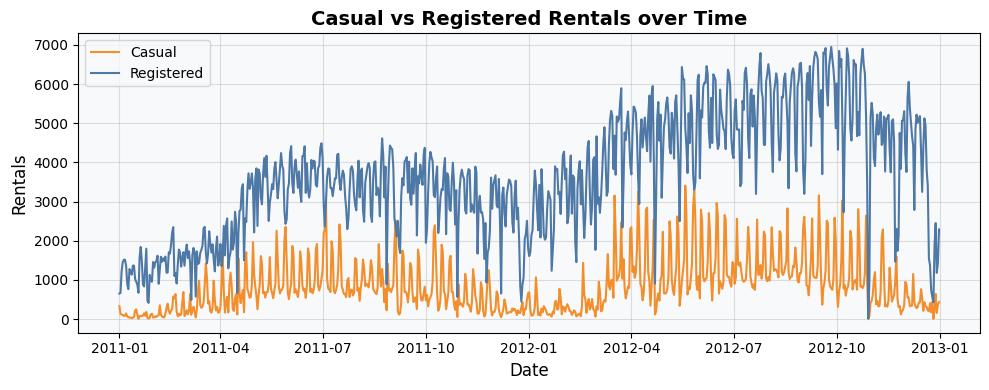

In [123]:
#Casual vs Registered split 
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['dteday'], df['casual'], label='Casual', color='#f28e2b')
ax.plot(df['dteday'], df['registered'], label='Registered', color='#4e79a7')

ax.set_title('Casual vs Registered Rentals over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rentals')
ax.legend()

plt.tight_layout()
plt.show()

In [124]:
df2 = df.copy()
df2['dayofyear']  = df2['dteday'].dt.dayofyear
df2['quarter']    = df2['dteday'].dt.quarter

In [125]:


# Cyclical encoding 
df2['mnth_sin']    = np.sin(2 * np.pi * df2['mnth']    / 12)
df2['mnth_cos']    = np.cos(2 * np.pi * df2['mnth']    / 12)
df2['weekday_sin'] = np.sin(2 * np.pi * df2['weekday'] / 7)
df2['weekday_cos'] = np.cos(2 * np.pi * df2['weekday'] / 7)

# Interaction features 
df2['temp_hum']        = df2['temp'] * df2['hum']
df2['temp_wind']       = df2['temp'] * df2['windspeed']
df2['is_summer_clear'] = ((df2['season'] == 3) & (df2['weathersit'] == 1)).astype(int)

# Comfort index (high temp + low humidity + low wind)
df2['comfort'] = df2['temp'] - 0.5 * df2['hum'] - 0.3 * df2['windspeed']

#Log target 
df2['log_cnt'] = np.log1p(df2['cnt'])

print(f'New shape: {df2.shape}')
print('New features:', [c for c in df2.columns if c not in df.columns])

New shape: (731, 27)
New features: ['dayofyear', 'quarter', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'temp_hum', 'temp_wind', 'is_summer_clear', 'comfort', 'log_cnt']


In [126]:
# ── Drop leakage columns & non-numeric ────────────────────────────────────────
DROP = ['instant', 'dteday', 'casual', 'registered', 'cnt', 'log_cnt']

FEATURES = [c for c in df2.columns if c not in DROP]
TARGET   = 'cnt'

X = df2[FEATURES]
y = df2[TARGET]
y_log = df2['log_cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED)

print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train: (584, 21)   Test: (147, 21)
Features (21): ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'dayofyear', 'quarter', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'temp_hum', 'temp_wind', 'is_summer_clear', 'comfort']


In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [128]:
baseline_pred  = np.full(len(y_test), y_train.mean())
baseline_rmse  = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2    = r2_score(y_test, baseline_pred)
print(f'Baseline (mean) → RMSE: {baseline_rmse:.1f}   R²: {baseline_r2:.4f}')

Baseline (mean) → RMSE: 2022.2   R²: -0.0198


In [129]:
results = []

linear_models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge (α=10)',      Ridge(alpha=10)),
    ('Lasso (α=5)',       Lasso(alpha=5, max_iter=5000)),
    ('ElasticNet',        ElasticNet(alpha=1, l1_ratio=0.5, max_iter=5000)),
    ('Huber',             HuberRegressor(max_iter=500)),
]

for name, model in linear_models:
    res = evaluate(name, model, X_train, X_test, y_train, y_test)
    results.append(res)
    print(f'{name:25s}  RMSE={res["RMSE"]}  R²={res["R²"]}  CV-RMSE={res["CV-RMSE"]}')

Linear Regression          RMSE=803.9  R²=0.8388  CV-RMSE=864.4
Ridge (α=10)               RMSE=799.9  R²=0.8404  CV-RMSE=848.4
Lasso (α=5)                RMSE=802.1  R²=0.8396  CV-RMSE=853.4
ElasticNet                 RMSE=934.1  R²=0.7824  CV-RMSE=961.2
Huber                      RMSE=805.5  R²=0.8382  CV-RMSE=867.5


In [130]:
tree_models = [
    ('Decision Tree',       DecisionTreeRegressor(max_depth=8, random_state=SEED)),
    ('Random Forest',       RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))
]

for name, model in tree_models:
    res = evaluate(name, model, X_train, X_test, y_train, y_test)
    results.append(res)
    print(f'{name:25s}  RMSE={res["RMSE"]}  R²={res["R²"]}  CV-RMSE={res["CV-RMSE"]}')

Decision Tree              RMSE=809.8  R²=0.8364  CV-RMSE=922.6
Random Forest              RMSE=625.0  R²=0.9026  CV-RMSE=682.7


In [131]:
# Train on log(cnt) and back-transform predictions
gb_log = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=4, random_state=SEED)
pipe_log = Pipeline([('prep', preprocessor), ('model', gb_log)])
pipe_log.fit(X_train, y_log_train)
pred_log = np.expm1(pipe_log.predict(X_test))

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
r2_log   = r2_score(y_test, pred_log)
results.append({'Model':'GBR (log target)', 'RMSE': round(rmse_log,1),
                'MAE': round(mean_absolute_error(y_test, pred_log),1),
                'R²': round(r2_log,4),
                'MAPE%': round(mean_absolute_percentage_error(y_test, pred_log)*100,2),
                'CV-RMSE': '—'})
print(f'GBR (log target)   RMSE={rmse_log:.1f}   R²={r2_log:.4f}')

GBR (log target)   RMSE=550.5   R²=0.9244
